<a href="https://colab.research.google.com/github/cu24250171/cu24250171-Divya-B.-Tech-CSE-A-3rd-year---Computer-Vision-labsheets/blob/main/LABSHEET_3_COMPUTER_VISION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LABSHEET- 3

NAME - DIVYA

CU24250171

B.TECH CSE 'A' 3RD YEAR

ROLL NO:- 17

SUBJECT - COMPUTER VISION LAB





1.build a noise-removal tool using Gaussian , median, and median filters , and compare their effectiveness on salt-and-pepper noise.

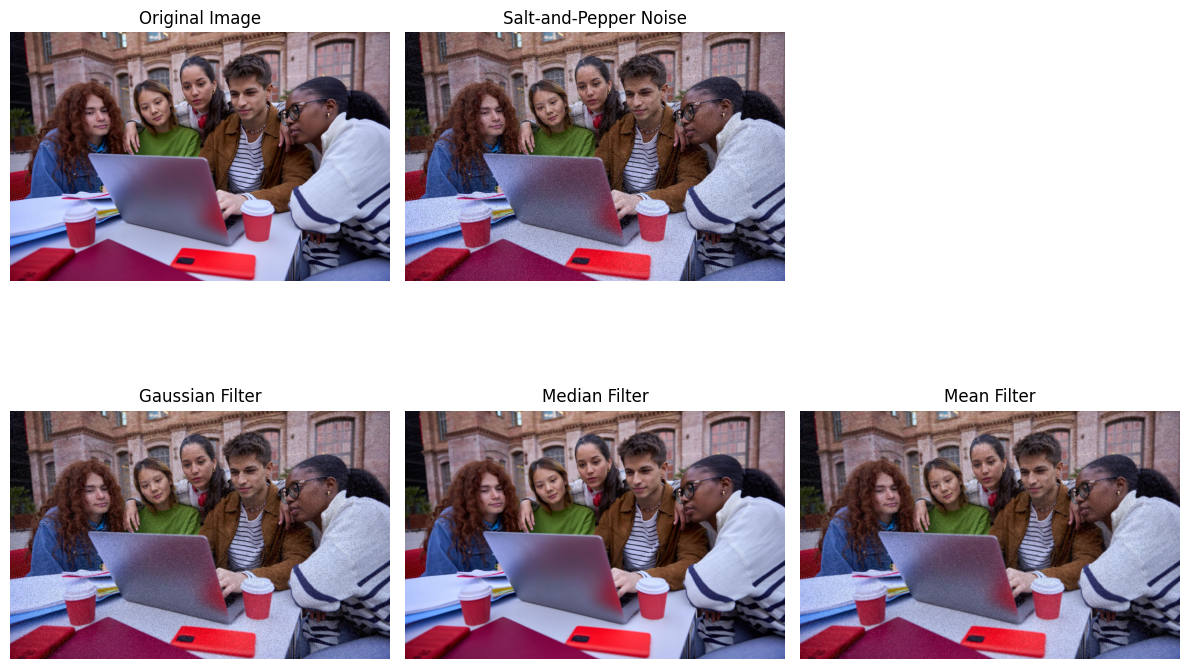

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("/content/image.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Add salt-and-pepper noise
noisy = image.copy()

# Salt noise
num_salt = int(0.02 * image.shape[0] * image.shape[1])
coords = [
    np.random.randint(0, i - 1, num_salt)
    for i in image.shape[:2]
]
noisy[coords[0], coords[1]] = 255

# Pepper noise
num_pepper = int(0.05 * image.shape[0] * image.shape[1])
coords = [
    np.random.randint(0, i - 1, num_pepper)
    for i in image.shape[:2]
]
noisy[coords[0], coords[1]] = 0

# Gaussian filter
gaussian = cv2.GaussianBlur(noisy, (5, 5), 0)

# Median filter
median = cv2.medianBlur(noisy, 5)

# Mean filter
mean = cv2.blur(noisy, (5, 5))

# Display results
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(noisy)
plt.title("Salt-and-Pepper Noise")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(gaussian)
plt.title("Gaussian Filter")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(median)
plt.title("Median Filter")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(mean)
plt.title("Mean Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

 2. Develop an edge-detection demo using high-pass filters (Laplacian and sobel kernels) and visualize the resulting edge maps.

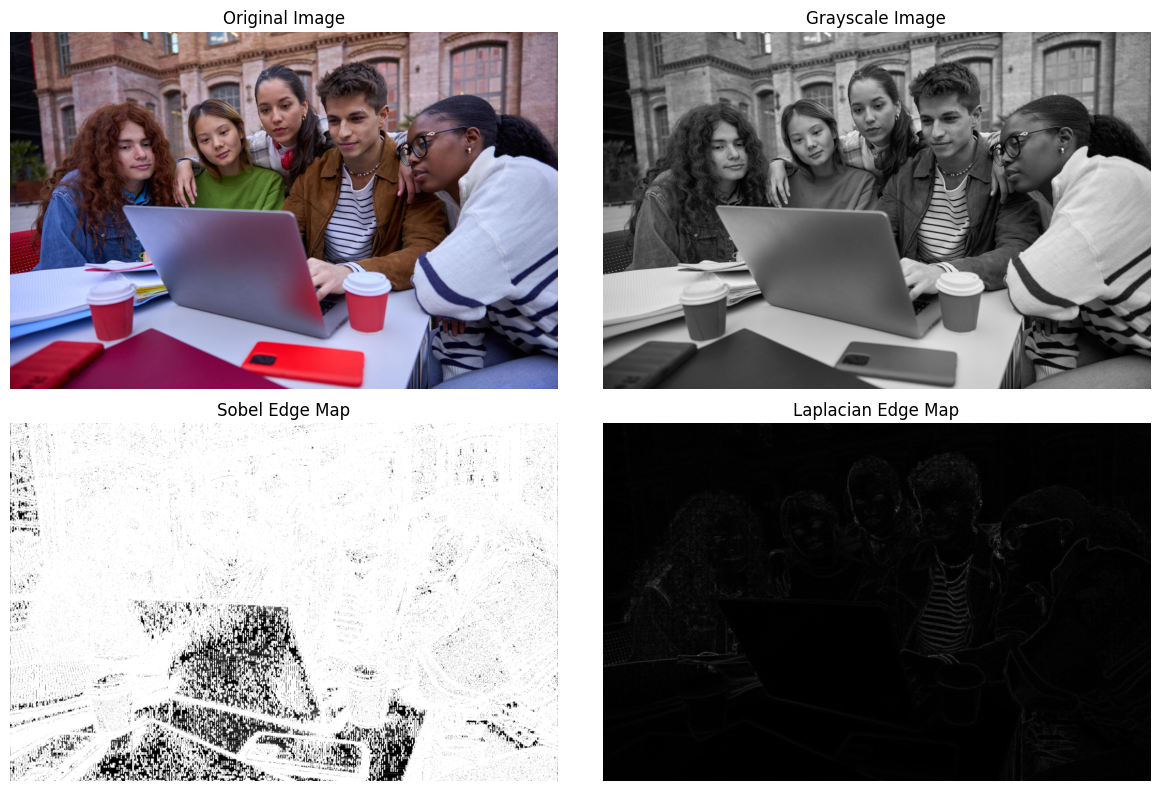

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("/content/image.jpg")

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Sobel edge detection
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=7)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)

# Combine horizontal and vertical edges
sobel = cv2.magnitude(sobel_x, sobel_y)

# Laplacian edge detection
laplacian = cv2.Laplacian(gray, cv2.CV_64F)

# Convert results to displayable format
sobel = cv2.convertScaleAbs(sobel)
laplacian = cv2.convertScaleAbs(laplacian)

# Display results
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(sobel, cmap="gray")
plt.title("Sobel Edge Map")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(laplacian, cmap="gray")
plt.title("Laplacian Edge Map")
plt.axis("off")

plt.tight_layout()
plt.show()

3. Create an interactive blur tool with an adjustable kernel size for real-time low-pass filtering.

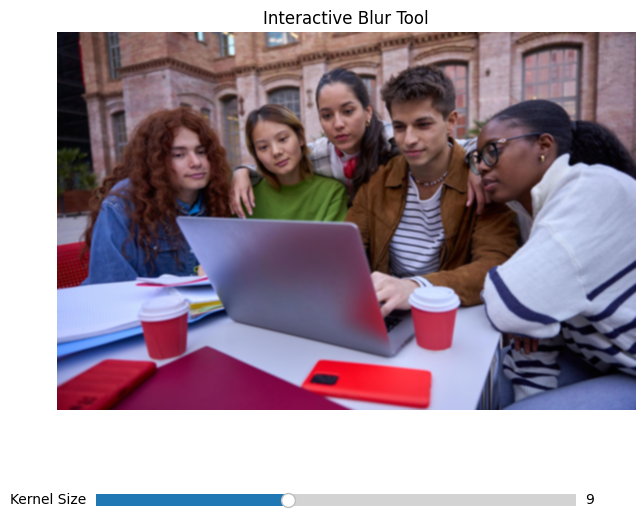

In [ ]:
import cv2
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# Read image
image = cv2.imread("/content/image.jpg")

# Convert BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))
plt.subplots_adjust(bottom=0.25)

# Initial kernel size
initial_kernel = 8

# Apply initial blur
blurred = cv2.blur(image, (initial_kernel, initial_kernel))

# Display image
img_display = ax.imshow(blurred)
ax.set_title("Interactive Blur Tool")
ax.axis("off")

# Create slider
slider_ax = plt.axes([0.2, 0.08, 0.6, 0.04])

kernel_slider = Slider(
    slider_ax,
    "Kernel Size",
    1,
    21,
    valinit=initial_kernel,
    valstep=2
)

# Update function
def update(val):
    kernel_size = int(kernel_slider.val)

    blurred = cv2.blur(
        image,
        (kernel_size, kernel_size)
    )

    img_display.set_data(blurred)
    fig.canvas.draw_idle()

# Connect slider to update function
kernel_slider.on_changed(update)

plt.show()

4. Build a sharpening tool that applies unsharp masking to enhance fine details in an image.

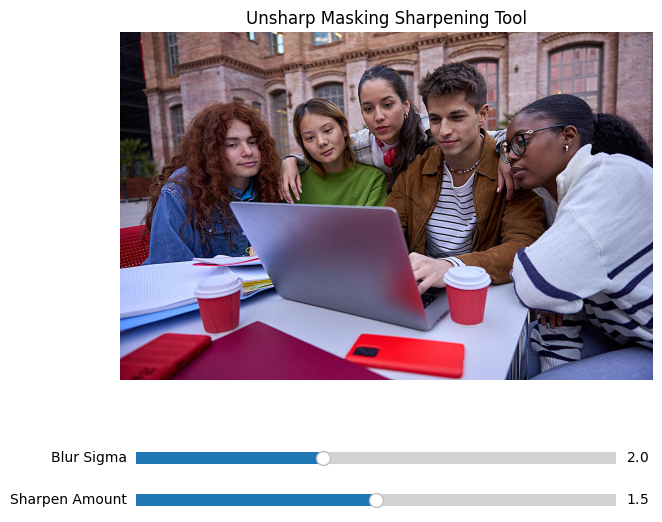

In [ ]:
import cv2
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# Read image
image = cv2.imread("image.jpg")

# Convert BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Initial values
initial_sigma = 2.0
initial_amount = 1.5

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))
plt.subplots_adjust(bottom=0.30)

# Create initial blurred image
blurred = cv2.GaussianBlur(
    image,
    (0, 0),
    initial_sigma
)

# Apply unsharp masking
sharpened = cv2.addWeighted(
    image,
    1 + initial_amount,
    blurred,
    -initial_amount,
    0
)

# Display image
img_display = ax.imshow(sharpened)
ax.set_title("Unsharp Masking Sharpening Tool")
ax.axis("off")

# Sigma slider
sigma_ax = plt.axes([0.2, 0.15, 0.6, 0.04])

sigma_slider = Slider(
    sigma_ax,
    "Blur Sigma",
    0.1,
    5.0,
    valinit=initial_sigma,
    valstep=0.1
)

# Amount slider
amount_ax = plt.axes([0.2, 0.08, 0.6, 0.04])

amount_slider = Slider(
    amount_ax,
    "Sharpen Amount",
    0.0,
    3.0,
    valinit=initial_amount,
    valstep=0.1
)

# Update function
def update(val):

    sigma = sigma_slider.val
    amount = amount_slider.val

    # Blur the image
    blurred = cv2.GaussianBlur(
        image,
        (0, 0),
        sigma
    )

    # Unsharp masking
    sharpened = cv2.addWeighted(
        image,
        1 + amount,
        blurred,
        -amount,
        0
    )

    # Update displayed image
    img_display.set_data(sharpened)

    fig.canvas.draw_idle()


# Connect sliders
sigma_slider.on_changed(update)
amount_slider.on_changed(update)

plt.show()

5. Develop a custom convolution kernel designer where users input their own kernel matrix and apply it to an image.

Enter your 3x3 convolution kernel.
Enter 9 values separated by spaces.
Enter kernel values: 3 3 3 5 6 7 1 4 3

Your kernel is:
[[3. 3. 3.]
 [5. 6. 7.]
 [1. 4. 3.]]


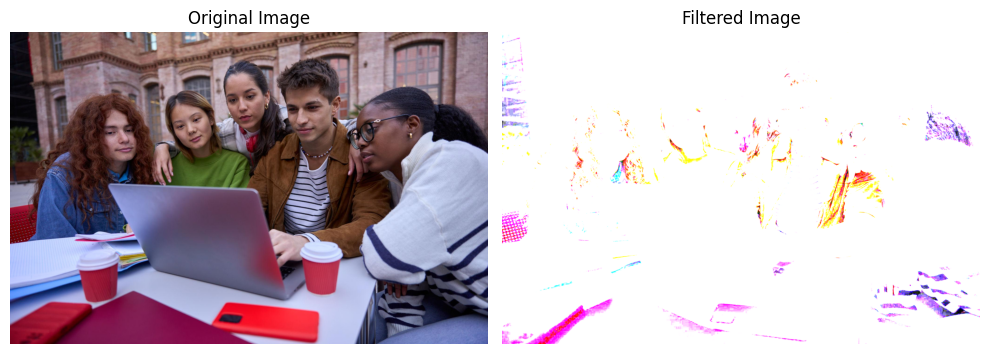

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("image.jpg")

# Convert BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display instructions
print("Enter your 3x3 convolution kernel.")
print("Enter 9 values separated by spaces.")

# Take kernel input
values = list(map(float, input("Enter kernel values: ").split()))

# Check input
if len(values) != 9:
    print("Error: Please enter exactly 9 values.")
else:

    # Create 3x3 kernel
    kernel = np.array(values).reshape(3, 3)

    print("\nYour kernel is:")
    print(kernel)

    # Apply convolution
    result = cv2.filter2D(image, -1, kernel)

    # Display images
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(result)
    plt.title("Filtered Image")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

6. Create a bilateral filtering demo that smooths an image while preserving edges, and compare it with standard Gaussian blur.

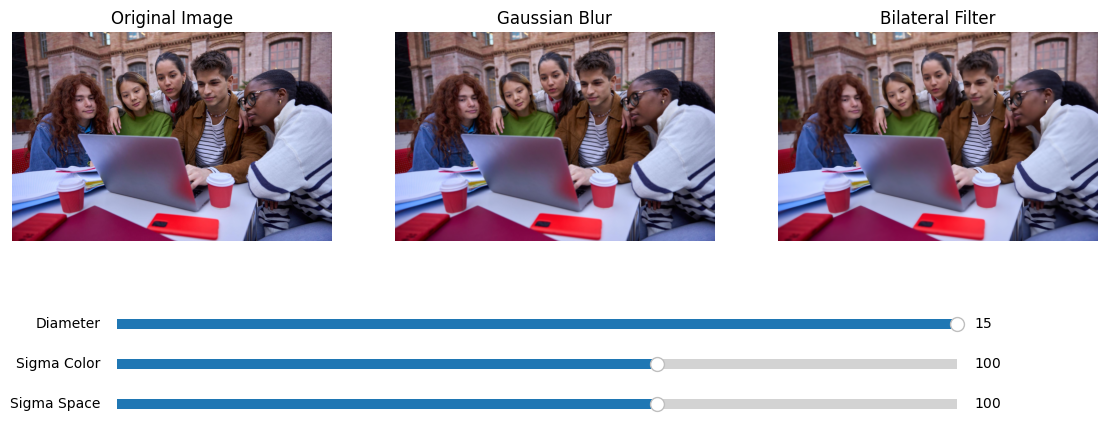

In [ ]:
import cv2
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# Read image
image = cv2.imread("image.jpg")

# Convert BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Initial values
initial_d = 15
initial_sigma_color = 100
initial_sigma_space = 100

# Apply initial Gaussian blur
gaussian = cv2.GaussianBlur(image, (9, 9), 0)

# Apply initial bilateral filter
bilateral = cv2.bilateralFilter(
    image,
    initial_d,
    initial_sigma_color,
    initial_sigma_space
)

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
plt.subplots_adjust(bottom=0.35)

# Display images
axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

gaussian_display = axes[1].imshow(gaussian)
axes[1].set_title("Gaussian Blur")
axes[1].axis("off")

bilateral_display = axes[2].imshow(bilateral)
axes[2].set_title("Bilateral Filter")
axes[2].axis("off")


# Slider 1: Diameter
d_ax = plt.axes([0.2, 0.22, 0.6, 0.04])

d_slider = Slider(
    d_ax,
    "Diameter",
    1,
    15,
    valinit=initial_d,
    valstep=2
)


# Slider 2: Sigma Color
color_ax = plt.axes([0.2, 0.14, 0.6, 0.04])

color_slider = Slider(
    color_ax,
    "Sigma Color",
    10,
    150,
    valinit=initial_sigma_color,
    valstep=5
)


# Slider 3: Sigma Space
space_ax = plt.axes([0.2, 0.06, 0.6, 0.04])

space_slider = Slider(
    space_ax,
    "Sigma Space",
    10,
    150,
    valinit=initial_sigma_space,
    valstep=5
)


# Update function
def update(val):

    d = int(d_slider.val)
    sigma_color = color_slider.val
    sigma_space = space_slider.val

    # Gaussian blur
    gaussian = cv2.GaussianBlur(
        image,
        (9, 9),
        0
    )

    # Bilateral filtering
    bilateral = cv2.bilateralFilter(
        image,
        d,
        sigma_color,
        sigma_space
    )

    # Update images
    gaussian_display.set_data(gaussian)
    bilateral_display.set_data(bilateral)

    fig.canvas.draw_idle()


# Connect sliders
d_slider.on_changed(update)
color_slider.on_changed(update)
space_slider.on_changed(update)

plt.show()

7. Build a denoising pipeline for old or scanned photographs using a combination of spatial filters.

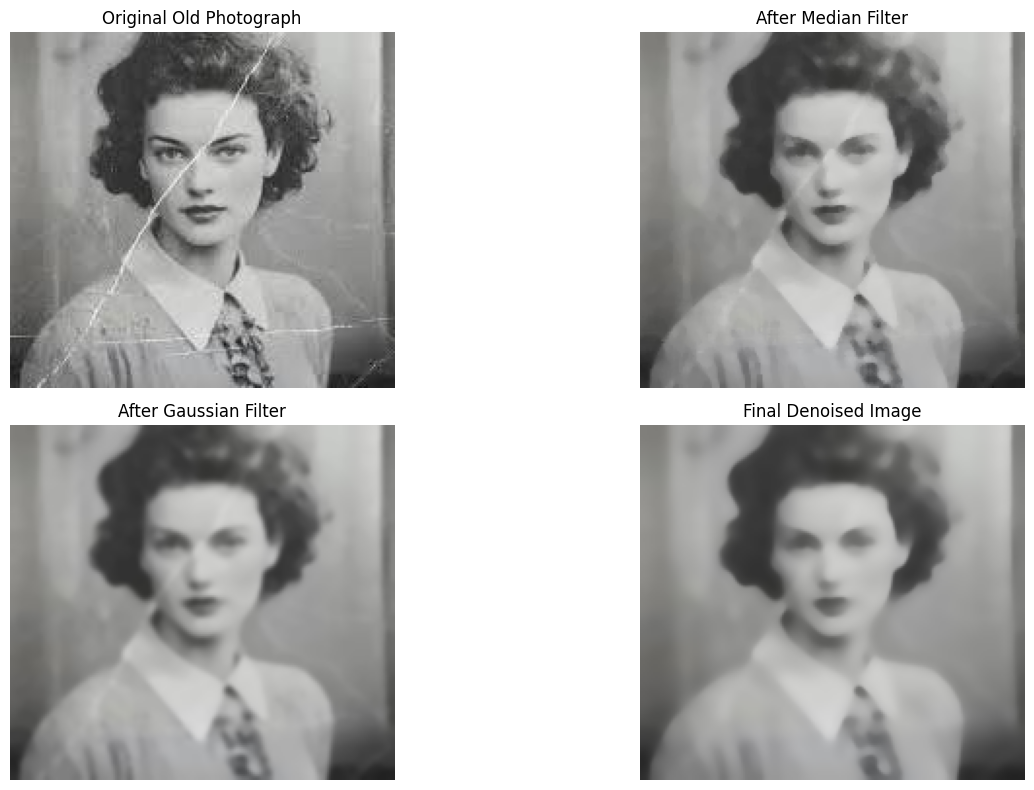

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("/content/old_photo.jpg")

# Convert BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Step 1: Median filtering
median = cv2.medianBlur(image, 5)

# Step 2: Gaussian filtering
gaussian = cv2.GaussianBlur(median, (5, 5), 0)

# Step 3: Bilateral filtering
bilateral = cv2.bilateralFilter(
    gaussian,
    9,
    75,
    75
)

# Display results
plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(image)
plt.title("Original Old Photograph")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(median)
plt.title("After Median Filter")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(gaussian)
plt.title("After Gaussian Filter")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(bilateral)
plt.title("Final Denoised Image")
plt.axis("off")

plt.tight_layout()
plt.show()

8. Develop a program that reduces simple motion-blur artifacts using high-pass sharpening techniques.

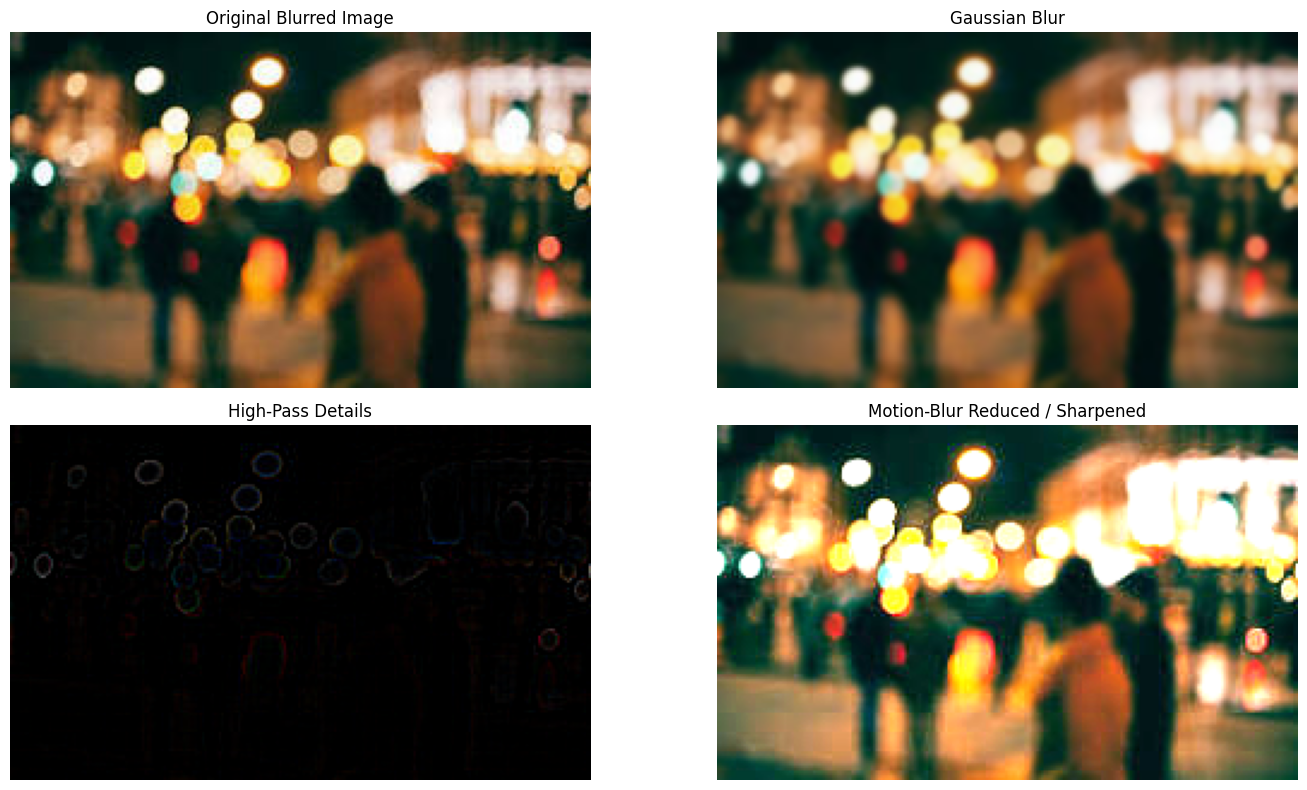

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("/content/blur.jpg")

# Convert BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Create a blurred version
blur = cv2.GaussianBlur(image, (5, 5), 0)

# Create high-pass detail image
high_pass = cv2.subtract(image, blur)

# Add high-frequency details to original image
sharpened = cv2.addWeighted(
    image, 1.5,
    high_pass, 1.0,
    0
)

# Display results
plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(image)
plt.title("Original Blurred Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(blur)
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(high_pass)
plt.title("High-Pass Details")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(sharpened)
plt.title("Motion-Blur Reduced / Sharpened")
plt.axis("off")

plt.tight_layout()
plt.show()

9. Create a "cartoonify" effect generator using edge detection combined with smoothing filters.

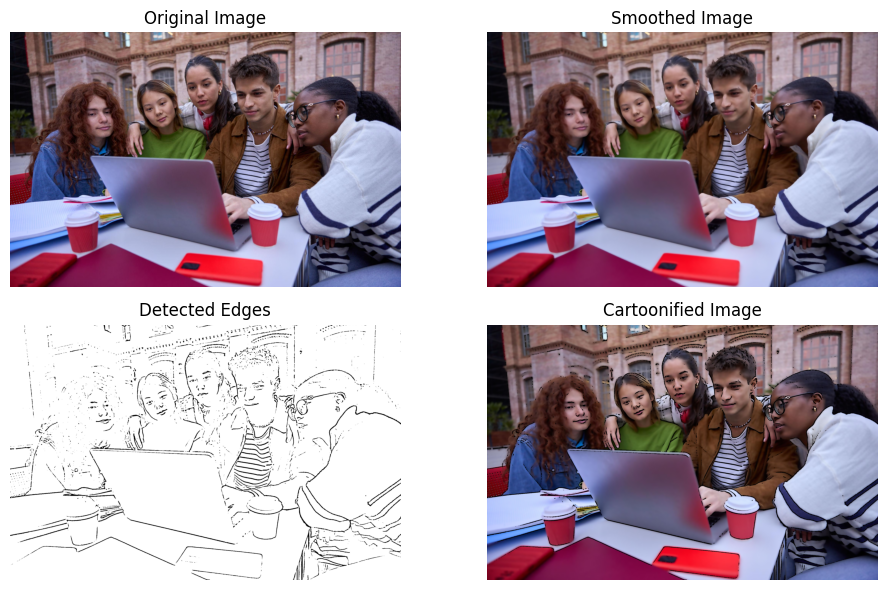

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("image.jpg")

# Convert BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Step 1: Smooth the image
smooth = cv2.bilateralFilter(image, 11, 75, 75)

# Step 2: Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# Step 3: Reduce noise
gray = cv2.medianBlur(gray, 5)

# Step 4: Detect edges
edges = cv2.adaptiveThreshold(
    gray,
    255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    9,
    9
)

# Step 5: Combine edges with smooth image
cartoon = cv2.bitwise_and(
    smooth,
    smooth,
    mask=edges
)

# Display results
plt.figure(figsize=(10, 6))

plt.subplot(2, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(smooth)
plt.title("Smoothed Image")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(edges, cmap="gray")
plt.title("Detected Edges")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(cartoon)
plt.title("Cartoonified Image")
plt.axis("off")

plt.tight_layout()
plt.show()

10. Build a comparison dashboard that reports PSNR/SSIM scores for different filtering techniques applied to the same noisy image.


PSNR / SSIM Comparison Dashboard


,Filter,PSNR (dB),SSIM
0,Noisy Image,18.06,0.2954
1,Gaussian,28.32,0.6567
2,Median,37.73,0.9557
3,Mean,29.49,0.7392
4,Bilateral,18.17,0.2960


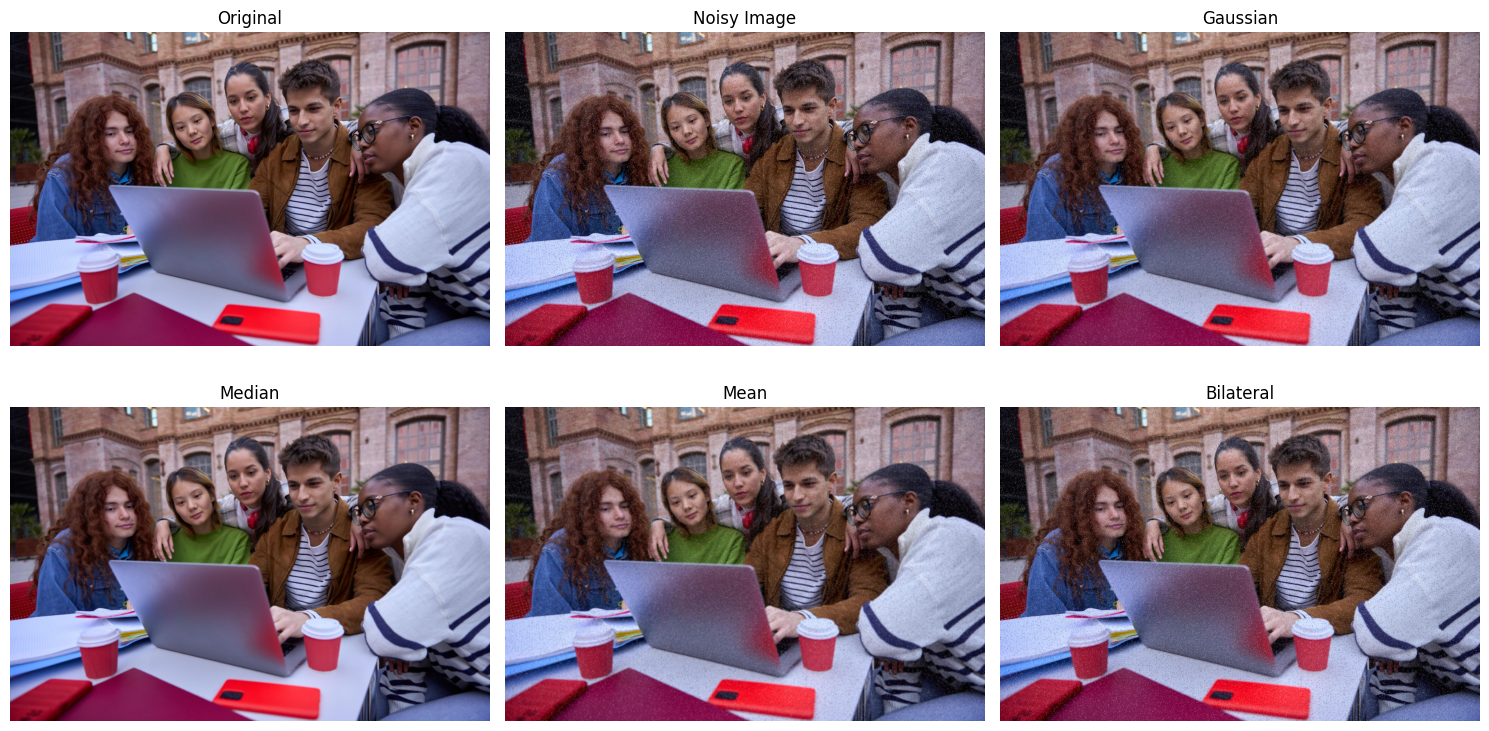

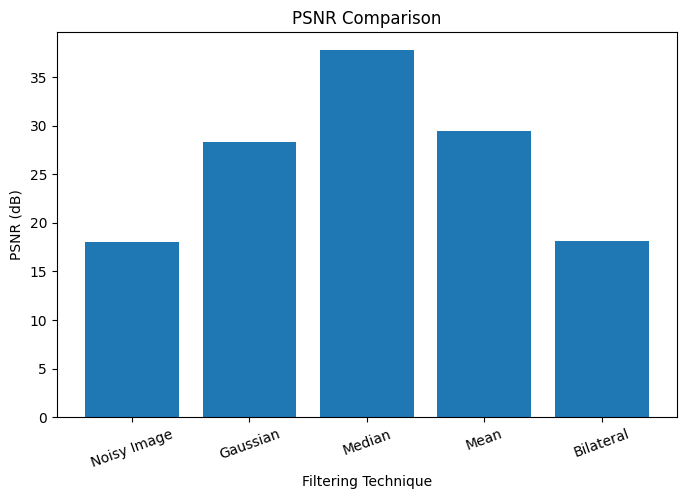

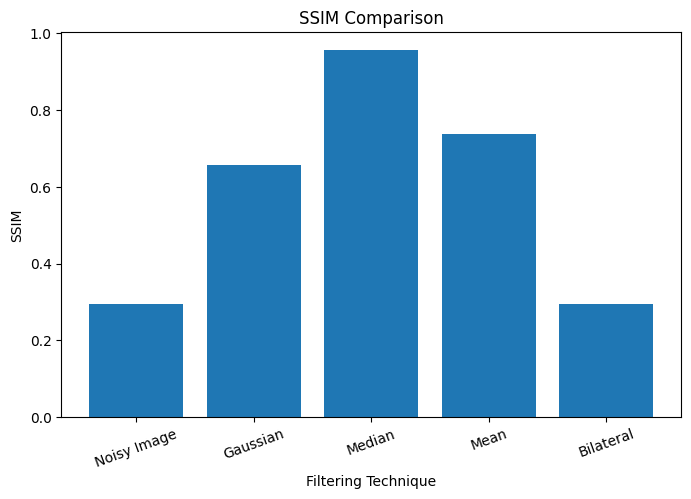

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity
# 1. Read Original Image
image = cv2.imread("image.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# 2. Add Salt-and-Pepper Noise
noisy = image.copy()
noise_amount = 0.05
num_pixels = int(noise_amount * image.shape[0] * image.shape[1])
for i in range(num_pixels):
    x = np.random.randint(0, image.shape[0])
    y = np.random.randint(0, image.shape[1])
    if np.random.rand() < 0.5:
        noisy[x, y] = 0
    else:
        noisy[x, y] = 255
# 3. Apply Different Filters
gaussian = cv2.GaussianBlur(noisy, (5, 5), 0)
median = cv2.medianBlur(noisy, 5)
mean = cv2.blur(noisy, (5, 5))
bilateral = cv2.bilateralFilter(
    noisy,
    9,
    75,
    75
)
# 4. Calculate PSNR and SSIM
results = []
filters = {
    "Noisy Image": noisy,
    "Gaussian": gaussian,
    "Median": median,
    "Mean": mean,
    "Bilateral": bilateral
}
for name, result in filters.items():
    psnr = peak_signal_noise_ratio(image, result)
    ssim = structural_similarity(
        image,
        result,
        channel_axis=2
    )
    results.append([
        name,
        round(psnr, 2),
        round(ssim, 4)
    ])
# 5. Create Dashboard Table
df = pd.DataFrame(
    results,
    columns=["Filter", "PSNR (dB)", "SSIM"]
)
print("PSNR / SSIM Comparison Dashboard")
display(df)
# 6. Display Images
plt.figure(figsize=(15, 8))
plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")
plt.subplot(2, 3, 2)
plt.imshow(noisy)
plt.title("Noisy Image")
plt.axis("off")
plt.subplot(2, 3, 3)
plt.imshow(gaussian)
plt.title("Gaussian")
plt.axis("off")
plt.subplot(2, 3, 4)
plt.imshow(median)
plt.title("Median")
plt.axis("off")
plt.subplot(2, 3, 5)
plt.imshow(mean)
plt.title("Mean")
plt.axis("off")
plt.subplot(2, 3, 6)
plt.imshow(bilateral)
plt.title("Bilateral")
plt.axis("off")
plt.tight_layout()
plt.show()
# 7. Plot PSNR Comparison
plt.figure(figsize=(8, 5))
plt.bar(df["Filter"], df["PSNR (dB)"])
plt.title("PSNR Comparison")
plt.xlabel("Filtering Technique")
plt.ylabel("PSNR (dB)")
plt.xticks(rotation=20)
plt.show()
# 8. Plot SSIM Comparison
plt.figure(figsize=(8, 5))
plt.bar(df["Filter"], df["SSIM"])
plt.title("SSIM Comparison")
plt.xlabel("Filtering Technique")
plt.ylabel("SSIM")
plt.xticks(rotation=20)
plt.show()